# AF agreement on panel-identical SNPs — SEEDMIX_S1 Chr1, v3qc_v3 filt2 vs hapFIRE

**Created 2026-05-20.** Isolates panel-genotype divergence from method divergence.

Two scatter panels:
- **Panel A**: every SNP where cactus_v3qc_v3 and hapFIRE_greneNet_v1.1 both call the same (chrom, pos, ref, alt). AF on x = hapFIRE, AF on y = cactus_em filt2. Tells us where the two methods agree even when they're nominally looking at the same variant.
- **Panel B**: subset where additionally the **per-founder genotype is identical for all 231 founders** between the two panels (both called, same allele). If the AFs still disagree here, the gap is from the EM / projection / k-mer→AF estimation itself, NOT from per-founder panel-call disagreement.

Join key per `feedback_freqk_parser_full_key` / `reference_hapfire_seedmix_canonical`: (chrom, pos, ref, alt) — never pos-only.

In [2]:
from matplotlib.colors import LogNorm
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import load_npz

ROOT = Path('/carnegie/nobackup/scratch/tbellagio/hapfire_sv')

# Cactus panel (v3qc_v3) — per-founder GT + meta
CACTUS_META   = ROOT / 'poolfreq/data/cn_var_231_v3qc_v3.meta.npz'
CACTUS_CNVAR  = ROOT / 'poolfreq/data/cn_var_231_v3qc_v3.cn_var.npz'
CACTUS_CALLED = ROOT / 'poolfreq/data/cn_var_231_v3qc_v3.cn_var_called.npz'

# cactus_em filt2 SEEDMIX_S1 output (one row per cn_var record, same order as meta)
CACTUS_AF_TSV = ROOT / 'scratch/v3qc_v3_filt2_chr1/SEEDMIX_S1.tsv'

# hapFIRE panel (greneNet_final_v1.1) + SEEDMIX_S1 per-SNP estimate
HAPFIRE_VCF   = Path('/carnegie/nobackup/scratch/xwu/GrENE_net/hapFIRE_updatedVCF/greneNet_final_v1.1_chr1.recode.vcf')
HAPFIRE_AF    = Path('/carnegie/nobackup/scratch/xwu/GrENE_net/hapFIRE_frequencies/seed_mix/s1_snp_frequency.txt')

/tmp/ipykernel_653002/2217989945.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 1. Cactus side — meta, GT, called mask, AF, restrict to Chr1 SNPs

In [3]:
meta = np.load(CACTUS_META, allow_pickle=True)
c_founders = np.asarray(meta['founders']).astype(str)
c_chrom = np.asarray(meta['chrom']).astype(str)
c_pos   = np.asarray(meta['pos']).astype(np.int64)
c_ref   = np.asarray(meta['ref'])   # leave as object — some ALTs are huge (multi-allelic SVs)
c_alt   = np.asarray(meta['alt'])   # converting to <U dtype tries to allocate ~2 TiB
c_rlen  = np.asarray(meta['ref_len']).astype(np.int64)
c_alen  = np.asarray(meta['alt_len']).astype(np.int64)
print(f'cactus meta: {len(c_pos):,} records, {len(c_founders)} founders')

# Filter to Chr1 SNPs using ref_len/alt_len BEFORE touching the ref/alt object arrays.
snp_mask_full = (c_chrom == 'Chr1') & (c_rlen == 1) & (c_alen == 1)
snp_idx = np.where(snp_mask_full)[0]
print(f'  Chr1 SNPs (ref_len=1, alt_len=1) in cactus panel: {snp_idx.size:,}')

# Only NOW pull ref/alt for the SNP subset and stringify those.
c_key_pos = c_pos[snp_idx]
c_key_ref = np.array([str(c_ref[i]) for i in snp_idx])
c_key_alt = np.array([str(c_alt[i]) for i in snp_idx])
del c_ref, c_alt  # free the giant object arrays
assert (np.char.str_len(c_key_ref) == 1).all() and (np.char.str_len(c_key_alt) == 1).all(), \
    'unexpected non-1bp allele after ref_len/alt_len=1 filter'

# AF from cactus_em filt2 — TSV row order == cn_var meta order
af_df = pd.read_csv(CACTUS_AF_TSV, sep='\t')
assert len(af_df) == len(c_pos), f'TSV row count mismatch {len(af_df)} vs {len(c_pos)}'
c_af = af_df['alt_freq'].to_numpy(dtype=np.float64)
del af_df
c_af_snp = c_af[snp_idx]
n_chr1_called = np.isfinite(c_af_snp).sum()
print(f'  Chr1 SNPs with finite cactus AF (filt2 ran here): {n_chr1_called:,}')

# Per-founder GT + called for Chr1 SNPs only (slice cn_var by snp_idx)
cn = load_npz(CACTUS_CNVAR).tocsc()
cd = load_npz(CACTUS_CALLED).tocsc()
c_gt    = cn[:, snp_idx].toarray().astype(np.int8)   # (231, n_snp_cact)
c_call  = cd[:, snp_idx].toarray().astype(np.int8)
del cn, cd
print(f'  cactus SNP GT matrix: shape={c_gt.shape}, alt-carrier nnz={(c_gt==1).sum():,}')
print(f'  cactus called fraction: {(c_call==1).mean():.3f}')

cactus meta: 6,293,085 records, 231 founders
  Chr1 SNPs (ref_len=1, alt_len=1) in cactus panel: 1,029,469
  Chr1 SNPs with finite cactus AF (filt2 ran here): 1,029,469
  cactus SNP GT matrix: shape=(231, 1029469), alt-carrier nnz=24,465,135
  cactus called fraction: 0.967


  cactus SNP GT matrix: shape=(231, 1029469), alt-carrier nnz=24,465,135


  cactus called fraction: 0.967


## 2. hapFIRE side — parse chr1 VCF, build (chrom,pos,ref,alt) + per-founder GT

In [4]:
# Parse VCF: header row -> sample IDs; data rows -> CHROM, POS, REF, ALT, GT per sample
# hapFIRE VCF uses chrom='1' (numeric), need to map to 'Chr1' for join.
import gzip

_open = gzip.open if str(HAPFIRE_VCF).endswith('.gz') else open
h_samples = None
rows_chrom = []; rows_pos = []; rows_ref = []; rows_alt = []; rows_gt = []
with _open(HAPFIRE_VCF, 'rt') as fh:
    for line in fh:
        if line.startswith('##'):
            continue
        if line.startswith('#CHROM'):
            cols = line.rstrip('\n').split('\t')
            h_samples = cols[9:]
            continue
        f = line.rstrip('\n').split('\t')
        rows_chrom.append(f'Chr{f[0]}')
        rows_pos.append(int(f[1]))
        rows_ref.append(f[2 + 1] if False else f[3])  # f[3]=REF
        rows_alt.append(f[4])
        # GT field is f[9:]; FORMAT col is f[8]. With FORMAT='GT' GT is the only sub-field.
        # Encode 0/0 -> 0, 1/1 -> 1, anything else (het, missing) -> -1.
        gtvec = np.empty(len(f) - 9, dtype=np.int8)
        for i, g in enumerate(f[9:]):
            # Most common cases first
            if g == '0/0' or g == '0|0':
                gtvec[i] = 0
            elif g == '1/1' or g == '1|1':
                gtvec[i] = 1
            else:
                gtvec[i] = -1  # het or missing
        rows_gt.append(gtvec)

h_chrom = np.asarray(rows_chrom)
h_pos   = np.asarray(rows_pos, dtype=np.int64)
h_ref   = np.asarray(rows_ref)
h_alt   = np.asarray(rows_alt)
h_gt    = np.vstack(rows_gt).T  # (n_samples, n_snps_hapfire)
h_samples = np.asarray(h_samples).astype(str)
print(f'hapFIRE chr1 VCF: {h_pos.size:,} SNPs, {len(h_samples)} samples')
print(f'  GT matrix shape: {h_gt.shape}')
print(f'  fraction 0/0: {(h_gt==0).mean():.3f}, 1/1: {(h_gt==1).mean():.3f}, het/missing: {(h_gt==-1).mean():.3f}')

hapFIRE chr1 VCF: 827,765 SNPs, 231 samples
  GT matrix shape: (231, 827765)
  fraction 0/0: 0.890, 1/1: 0.110, het/missing: 0.000


## 3. Align hapFIRE founder order to cactus founder order

In [5]:
h_sample_idx = {s: i for i, s in enumerate(h_samples)}
h_to_c_perm = np.array([h_sample_idx[f] for f in c_founders if f in h_sample_idx])
assert h_to_c_perm.size == len(c_founders), 'cactus founder missing from hapFIRE VCF'
h_gt = h_gt[h_to_c_perm, :]   # reorder rows to match cactus founder order
print(f'hapFIRE GT reordered to cactus founder order: shape={h_gt.shape}')

hapFIRE GT reordered to cactus founder order: shape=(231, 827765)


## 4. Join on (chrom, pos, ref, alt) — Panel A

In [6]:
# Key arrays for the cactus side already built in cell 1 (c_key_pos/ref/alt, c_af_snp).
# DataFrame-based join (both sides ~1M / ~800k rows)
df_c = pd.DataFrame({'pos': c_key_pos, 'ref': c_key_ref, 'alt': c_key_alt,
                     'cactus_idx': np.arange(snp_idx.size), 'cactus_af': c_af_snp})
df_h = pd.DataFrame({'pos': h_pos, 'ref': h_ref, 'alt': h_alt,
                     'hapfire_idx': np.arange(h_pos.size)})

# Load hapFIRE per-SNP AF for SEEDMIX_S1
haf = pd.read_csv(HAPFIRE_AF, sep='\t', header=None, names=['chrom_num','pos','hapfire_af'])
haf = haf[haf['chrom_num'] == 1].drop(columns='chrom_num')
# hapFIRE SNP-freq is pos-only — but hapFIRE panel is biallelic per (chrom,pos), so
# joining to df_h on pos resolves uniquely to that pos's (ref,alt).
df_h = df_h.merge(haf, on='pos', how='left')
print(f'hapFIRE chr1 SNPs with finite AF: {df_h["hapfire_af"].notna().sum():,}/{len(df_h):,}')

merged = df_c.merge(df_h, on=['pos','ref','alt'], how='inner')
print(f'\nPanel A — (chrom,pos,ref,alt) match between cactus and hapFIRE panels:')
print(f'  cactus Chr1 SNPs: {snp_idx.size:,}')
print(f'  hapFIRE chr1 SNPs: {h_pos.size:,}')
print(f'  matched on (pos,ref,alt): {len(merged):,}')
print(f'  matched AND finite AF on both sides: {merged.dropna(subset=["cactus_af","hapfire_af"]).shape[0]:,}')

hapFIRE chr1 SNPs with finite AF: 827,765/827,765

Panel A — (chrom,pos,ref,alt) match between cactus and hapFIRE panels:
  cactus Chr1 SNPs: 1,029,469
  hapFIRE chr1 SNPs: 827,765
  matched on (pos,ref,alt): 518,576
  matched AND finite AF on both sides: 518,576


## 5. Refine to per-founder GT identity — Panel B

For each (pos,ref,alt)-matched SNP, compare per-founder GT between cactus (binary 0/1 + called mask) and hapFIRE (0=REF/REF, 1=ALT/ALT, -1=het/missing). The variant passes Panel B iff for every one of the 231 founders, the call exists on both sides AND the allele state matches.

In [7]:
c_idx_arr = merged['cactus_idx'].to_numpy()
h_idx_arr = merged['hapfire_idx'].to_numpy()

# Slice GT matrices to the matched columns
C_gt   = c_gt[:,   c_idx_arr]            # cactus 0/1
C_call = c_call[:, c_idx_arr] == 1       # cactus called mask
H_gt   = h_gt[:,   h_idx_arr]            # hapFIRE 0/1/-1
H_call = H_gt != -1                      # hapFIRE called mask (not het/missing)

# Both called AND same allele state
both_called = C_call & H_call
agree_when_called = (C_gt == H_gt) & both_called   # (231, n_matched)

# Per-variant: how many founders called on both sides, of those how many agree
n_both = both_called.sum(axis=0)
n_agree = agree_when_called.sum(axis=0)
agree_frac = np.where(n_both > 0, n_agree / np.maximum(n_both, 1), np.nan)

# Strict Panel B: all 231 founders called on both sides AND all agree
panel_b_strict = (n_both == 231) & (n_agree == 231)
# Looser: relax to >=200 called on both sides AND all those agree (for sample-size sanity)
panel_b_loose = (n_both >= 200) & (n_agree == n_both)

merged['n_founders_called_both'] = n_both
merged['n_founders_agree'] = n_agree
merged['agree_frac'] = agree_frac
merged['panel_b_strict'] = panel_b_strict
merged['panel_b_loose']  = panel_b_loose

print(f'Panel B (strict — 231/231 called both sides & all agree): {panel_b_strict.sum():,} / {len(merged):,} '
      f'({100*panel_b_strict.mean():.2f}%)')
print(f'Panel B (loose  — ≥200 called both & all called agree):    {panel_b_loose.sum():,} / {len(merged):,} '
      f'({100*panel_b_loose.mean():.2f}%)')
print('\nAgreement fraction distribution across (pos,ref,alt)-matched SNPs:')
print(pd.Series(agree_frac).describe(percentiles=[0.05,0.25,0.5,0.75,0.95]).to_string())

Panel B (strict — 231/231 called both sides & all agree): 118,407 / 518,576 (22.83%)
Panel B (loose  — ≥200 called both & all called agree):    237,143 / 518,576 (45.73%)

Agreement fraction distribution across (pos,ref,alt)-matched SNPs:
count    518576.000000
mean          0.990151
std           0.036002
min           0.011236
5%            0.963731
25%           0.991189
50%           0.995671
75%           1.000000
95%           1.000000
max           1.000000


## 6. Plot — Panel A vs Panel B

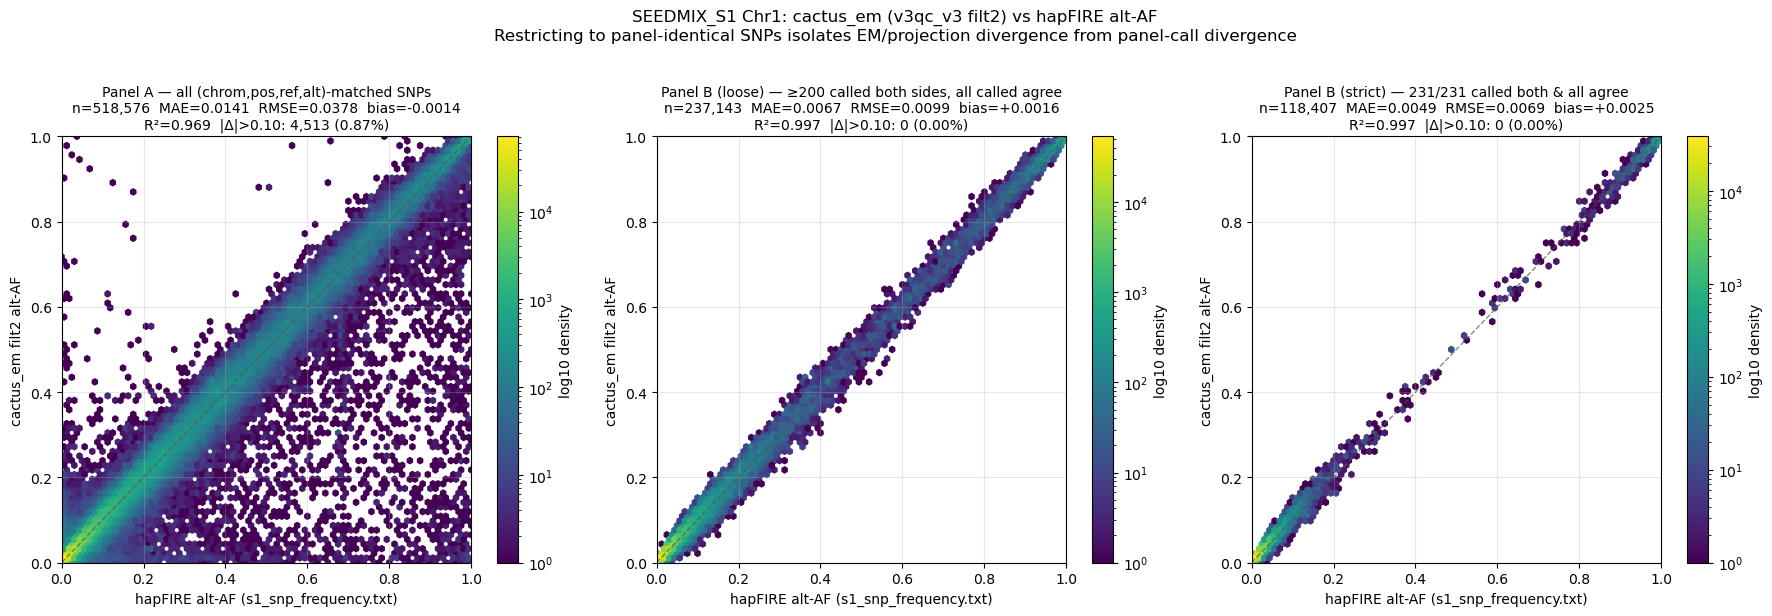

In [8]:
def af_scatter(ax, x, y, title):
    finite = np.isfinite(x) & np.isfinite(y)
    x, y = x[finite], y[finite]
    if x.size == 0:
        ax.text(0.5, 0.5, 'no points', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title); return
    h = ax.hexbin(x, y, gridsize=80, cmap='viridis', mincnt=1, norm=__import__('matplotlib.colors', fromlist=['LogNorm']).LogNorm(),
                  extent=(0,1,0,1))
    ax.plot([0,1],[0,1], color='#555555', ls='--', lw=1, alpha=0.7)
    mae = np.mean(np.abs(y - x))
    rmse = np.sqrt(np.mean((y - x)**2))
    bias = np.mean(y - x)
    r2 = np.corrcoef(x, y)[0,1]**2
    over = np.sum(np.abs(y - x) > 0.10)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('hapFIRE alt-AF (s1_snp_frequency.txt)')
    ax.set_ylabel('cactus_em filt2 alt-AF')
    ax.set_title(f'{title}\nn={x.size:,}  MAE={mae:.4f}  RMSE={rmse:.4f}  bias={bias:+.4f}\n'
                 f'R²={r2:.3f}  |Δ|>0.10: {over:,} ({100*over/x.size:.2f}%)', fontsize=10)
    ax.grid(alpha=0.3)
    plt.colorbar(h, ax=ax, label='log10 density')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel A: all (pos,ref,alt)-matched SNPs
af_scatter(axes[0], merged['hapfire_af'].to_numpy(), merged['cactus_af'].to_numpy(),
           'Panel A — all (chrom,pos,ref,alt)-matched SNPs')

# Panel B loose: same plus per-founder GT agree where both called, >=200 founders called both sides
sub = merged[merged['panel_b_loose']]
af_scatter(axes[1], sub['hapfire_af'].to_numpy(), sub['cactus_af'].to_numpy(),
           'Panel B (loose) — ≥200 called both sides, all called agree')

# Panel B strict: 231/231 both called and all agree
sub = merged[merged['panel_b_strict']]
af_scatter(axes[2], sub['hapfire_af'].to_numpy(), sub['cactus_af'].to_numpy(),
           'Panel B (strict) — 231/231 called both & all agree')

fig.suptitle('SEEDMIX_S1 Chr1: cactus_em (v3qc_v3 filt2) vs hapFIRE alt-AF\n'
             'Restricting to panel-identical SNPs isolates EM/projection divergence from panel-call divergence',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('plots/AF_PANEL_AGREEMENT_v3qc_v3_filt2_S1_chr1.png', dpi=140, bbox_inches='tight')
plt.show()

## 7. Summary table

In [9]:
def row(name, sub):
    x = sub['hapfire_af'].to_numpy(); y = sub['cactus_af'].to_numpy()
    finite = np.isfinite(x) & np.isfinite(y)
    x, y = x[finite], y[finite]
    if x.size == 0:
        return {'subset': name, 'n': 0}
    return {'subset': name, 'n': x.size,
            'MAE': float(np.mean(np.abs(y - x))),
            'RMSE': float(np.sqrt(np.mean((y - x)**2))),
            'bias_cactus_minus_hapfire': float(np.mean(y - x)),
            'R2': float(np.corrcoef(x, y)[0,1]**2),
            'frac_|delta|>0.10': float(np.mean(np.abs(y - x) > 0.10))}

rows = [
    row('A: all (pos,ref,alt) match', merged),
    row('B loose: ≥200 called both, all agree', merged[merged['panel_b_loose']]),
    row('B strict: 231/231 called & agree', merged[merged['panel_b_strict']]),
]
pd.set_option('display.float_format', lambda v: f'{v:.5f}' if abs(v) < 100 else f'{v:.0f}')
print(pd.DataFrame(rows).to_string(index=False))

                              subset      n     MAE    RMSE  bias_cactus_minus_hapfire      R2  frac_|delta|>0.10
          A: all (pos,ref,alt) match 518576 0.01412 0.03782                   -0.00135 0.96878            0.00870
B loose: ≥200 called both, all agree 237143 0.00668 0.00989                    0.00158 0.99653            0.00000
    B strict: 231/231 called & agree 118407 0.00489 0.00694                    0.00255 0.99718            0.00000


## 8. Atomized cn_var — same Panel A / B analysis

Repeat the panel-agreement analysis using the **Arch 3 atomized cn_var** (`cn_var_231_arch3_chr1_atomized`) and the corresponding filt2 AF projection (`arch3/chr1/SEEDMIX_S1_arch3_chr1_atomized.tsv` re-projected with the filt2 h — loaded from `SEEDMIX_S1_chr1_filt2_vs_mixedloose_vs_hapfire.tsv` column `af_filt2`).

The atomized cn_var decomposes MNPs to per-base SNP rows, so (pos, ref, alt) now matches hapFIRE SNPs that were previously mis-encoded. Expect Panel A n to increase and Panel B strict agreement to improve.


In [10]:
from matplotlib.colors import LogNorm

ARCH = ROOT / 'arch3' / 'chr1'
ATOM_META   = ARCH / 'cn_var_231_arch3_chr1_atomized.meta.npz'
ATOM_CNVAR  = ARCH / 'cn_var_231_arch3_chr1_atomized.cn_var.npz'
ATOM_CALLED = ARCH / 'cn_var_231_arch3_chr1_atomized.cn_var_called.npz'
# filt2 AF for atomized records — from F1 job output (af_filt2 column)
ATOM_AF_TSV = ARCH / 'SEEDMIX_S1_chr1_filt2_vs_mixedloose_vs_hapfire.tsv'

print('=== Load atomized meta + cn_var ===')
a_meta   = np.load(ATOM_META, allow_pickle=True)
a_founders = np.asarray(a_meta['founders']).astype(str)
a_chrom  = np.asarray(a_meta['chrom']).astype(str)
a_pos    = np.asarray(a_meta['pos']).astype(np.int64)
a_ref    = np.asarray([str(r) for r in a_meta['ref']])
a_alt    = np.asarray([str(r) for r in a_meta['alt']])
a_rlen   = np.asarray(a_meta['ref_len']).astype(np.int32)
a_alen   = np.asarray(a_meta['alt_len']).astype(np.int32)

# Restrict to Chr1 SNPs
a_snp_idx = np.where((a_chrom == 'Chr1') & (a_rlen == 1) & (a_alen == 1))[0]
print(f'  atomized Chr1 SNPs: {a_snp_idx.size:,}')

a_key_pos = a_pos[a_snp_idx]
a_key_ref = a_ref[a_snp_idx]
a_key_alt = a_alt[a_snp_idx]

print('  loading cn_var + called (sparse) ...')
a_gt_full   = load_npz(ATOM_CNVAR).tocsc()
a_call_full = load_npz(ATOM_CALLED).tocsc()

# Check founder ordering matches hapFIRE (reuse h_to_c_perm logic)
assert list(a_founders) == list(c_founders), 'atomized founders != cactus founders'

# Load filt2 AF for atomized records
# F1 TSV has (chrom_num, pos, ref, alt, af_hapfire, af_old, af_filt2)
print('=== Load filt2 AF for atomized records ===')
f1 = pd.read_csv(ATOM_AF_TSV, sep='\t')
print(f'  F1 TSV rows: {len(f1):,}')
# This TSV is already the 4-tuple join of atomized against hapFIRE
# af_filt2 = filt2 h projected through atomized cn_var

# Build index from (pos, ref, alt) -> row in a_snp_idx for GT slicing
a_snp_key_map = {(int(a_key_pos[i]), a_key_ref[i], a_key_alt[i]): i
                 for i in range(a_snp_idx.size)}

# Join F1 (atomized+hapFIRE) with atomized SNP index
print('=== Join F1 (atomized∩hapFIRE) → atomized SNP GT index ===')
f1_snp_idx_list = []
for _, r in f1.iterrows():
    key = (int(r['pos']), str(r['ref']), str(r['alt']))
    f1_snp_idx_list.append(a_snp_key_map.get(key, -1))
f1['a_snp_idx'] = f1_snp_idx_list
f1_matched = f1[f1['a_snp_idx'] >= 0].copy().reset_index(drop=True)
print(f'  matched to atomized SNP GT index: {len(f1_matched):,} / {len(f1):,}')

# Build hapFIRE GT index for matched rows (reuse h_pos/ref/alt + h_gt from prior cells)
h_key_map = {(int(h_pos[i]), h_ref[i], h_alt[i]): i for i in range(len(h_pos))}
f1_h_idx_list = [h_key_map.get((int(r['pos']), str(r['ref']), str(r['alt'])), -1)
                 for _, r in f1_matched.iterrows()]
f1_matched['h_idx'] = f1_h_idx_list
f1_matched = f1_matched[f1_matched['h_idx'] >= 0].copy().reset_index(drop=True)
print(f'  with hapFIRE GT index: {len(f1_matched):,}')

# === Panel B for atomized ===
print('=== Computing Panel B GT agreement (atomized) ===')
a_idx_arr = a_snp_idx[f1_matched['a_snp_idx'].to_numpy()]
h_idx_arr2 = f1_matched['h_idx'].to_numpy()

A_gt   = a_gt_full[:,   a_idx_arr].toarray()          # (231, n)
A_call = a_call_full[:, a_idx_arr].toarray() == 1
H_gt2  = h_gt[:, h_idx_arr2]                          # (231, n)
H_call2 = H_gt2 != -1

both_called_a = A_call & H_call2
agree_a = (A_gt == H_gt2) & both_called_a
n_both_a  = both_called_a.sum(axis=0)
n_agree_a = agree_a.sum(axis=0)

f1_matched['panel_b_strict'] = (n_both_a == 231) & (n_agree_a == 231)
f1_matched['panel_b_loose']  = (n_both_a >= 200) & (n_agree_a == n_both_a)

print(f'  Panel B strict: {f1_matched["panel_b_strict"].sum():,} / {len(f1_matched):,} '
      f'({100*f1_matched["panel_b_strict"].mean():.2f}%)')
print(f'  Panel B loose:  {f1_matched["panel_b_loose"].sum():,} / {len(f1_matched):,} '
      f'({100*f1_matched["panel_b_loose"].mean():.2f}%)')


=== Load atomized meta + cn_var ===
  atomized Chr1 SNPs: 7,464,709
  loading cn_var + called (sparse) ...
=== Load filt2 AF for atomized records ===
  F1 TSV rows: 711,669
=== Join F1 (atomized∩hapFIRE) → atomized SNP GT index ===
  matched to atomized SNP GT index: 711,669 / 711,669
  with hapFIRE GT index: 711,669
=== Computing Panel B GT agreement (atomized) ===
  Panel B strict: 123,221 / 711,669 (17.31%)
  Panel B loose:  256,927 / 711,669 (36.10%)


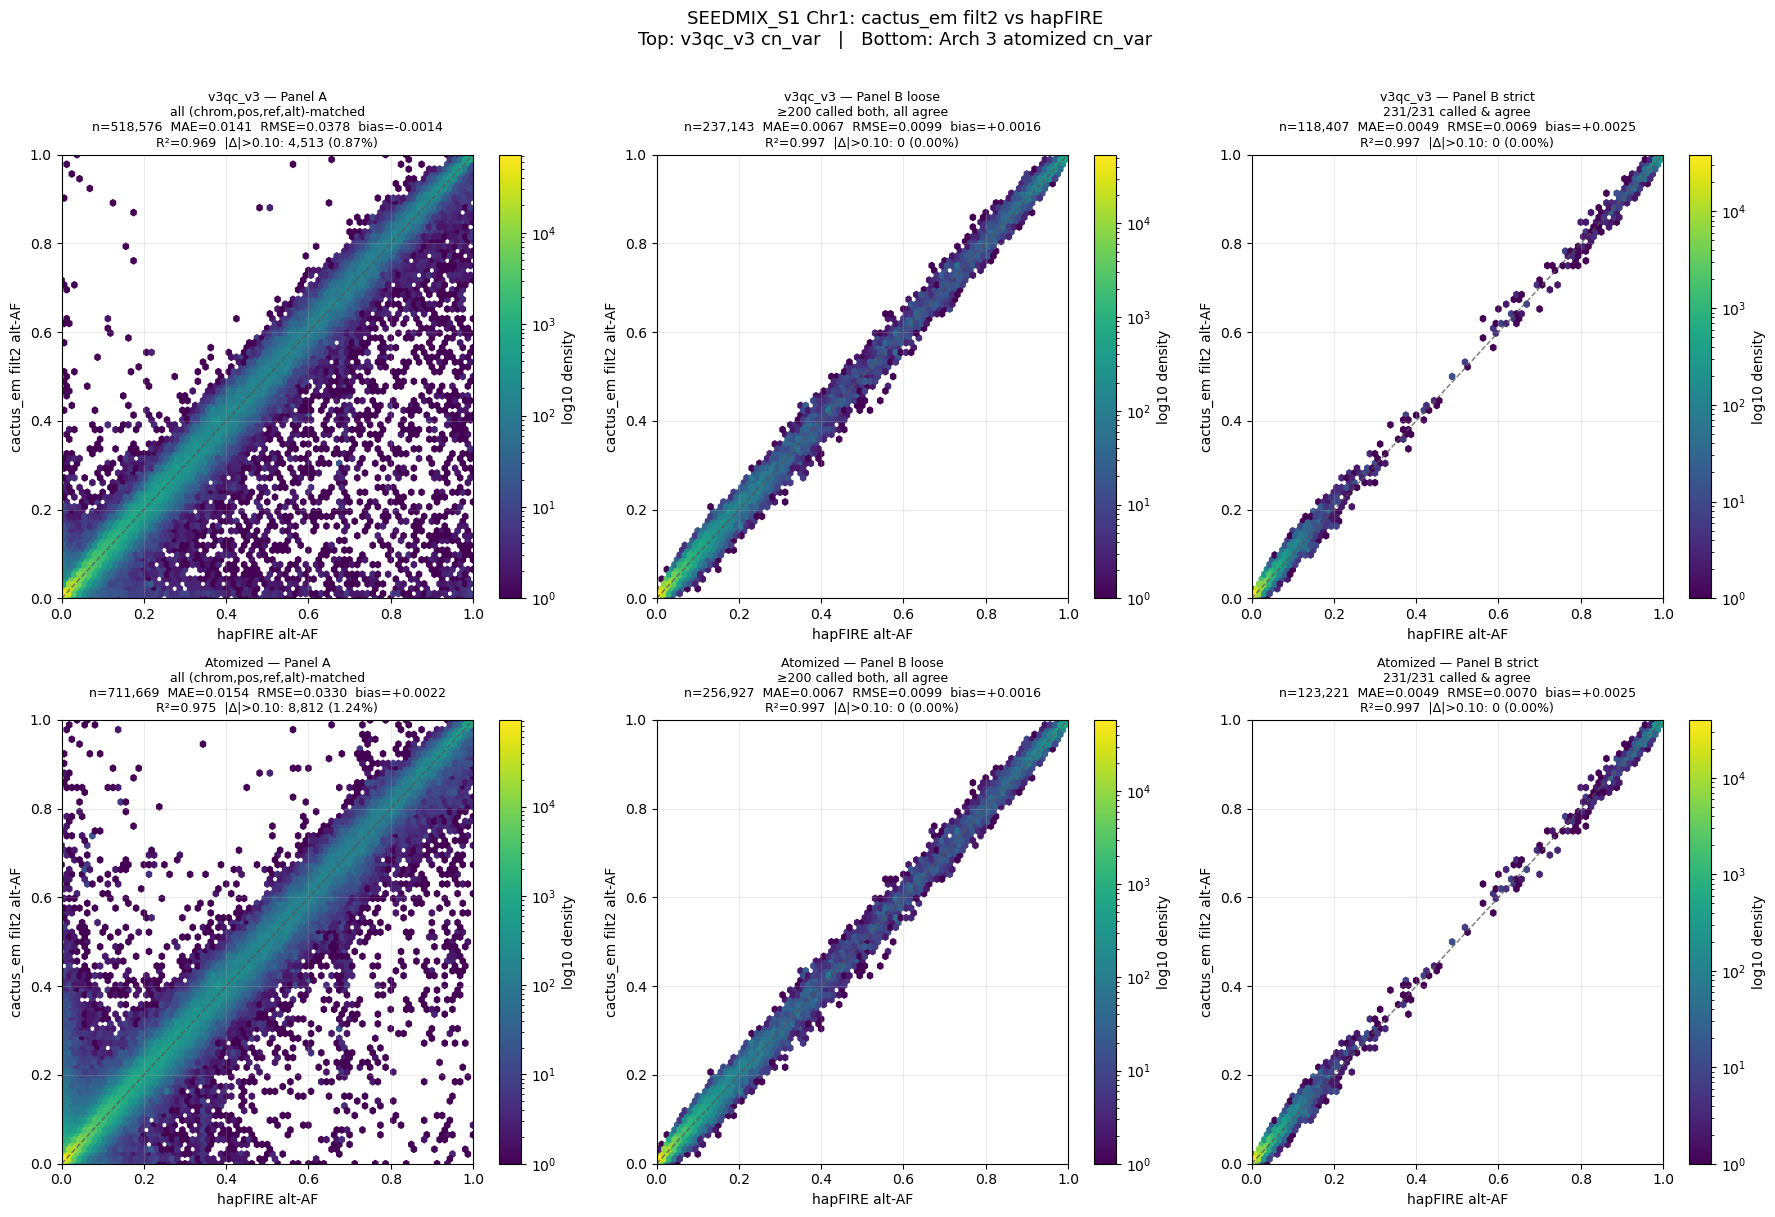

                            subset      n     MAE    RMSE     bias      R2  |Δ|>0.10
         v3qc_v3  — A: all matched 518576 0.01412 0.03782 -0.00135 0.96878   0.00870
    v3qc_v3  — B loose: ≥200 agree 237143 0.00668 0.00989  0.00158 0.99653   0.00000
v3qc_v3  — B strict: 231/231 agree 118407 0.00489 0.00694  0.00255 0.99718   0.00000
         Atomized — A: all matched 711669 0.01542 0.03302  0.00224 0.97470   0.01238
    Atomized — B loose: ≥200 agree 256927 0.00668 0.00989  0.00156 0.99658   0.00000
Atomized — B strict: 231/231 agree 123221 0.00490 0.00696  0.00255 0.99730   0.00000


In [11]:
def af_scatter_v2(ax, x, y, title):
    finite = np.isfinite(x) & np.isfinite(y)
    x, y = x[finite], y[finite]
    if x.size == 0:
        ax.text(0.5, 0.5, 'no points', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title); return
    h = ax.hexbin(x, y, gridsize=80, cmap='viridis', norm=LogNorm(), mincnt=1,
                  extent=(0,1,0,1))
    ax.plot([0,1],[0,1], color='#555555', ls='--', lw=1, alpha=0.8)
    mae  = np.mean(np.abs(y - x))
    rmse = np.sqrt(np.mean((y - x)**2))
    bias = np.mean(y - x)
    r2   = np.corrcoef(x, y)[0,1]**2
    over = np.sum(np.abs(y - x) > 0.10)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('hapFIRE alt-AF')
    ax.set_ylabel('cactus_em filt2 alt-AF')
    ax.set_title(f'{title}\nn={x.size:,}  MAE={mae:.4f}  RMSE={rmse:.4f}  bias={bias:+.4f}\n'
                 f'R²={r2:.3f}  |Δ|>0.10: {over:,} ({100*over/x.size:.2f}%)', fontsize=9)
    ax.grid(alpha=0.25)
    plt.colorbar(h, ax=ax, label='log10 density')

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 0: v3qc_v3 (existing merged)
af_scatter_v2(axes[0,0], merged['hapfire_af'].to_numpy(), merged['cactus_af'].to_numpy(),
              'v3qc_v3 — Panel A\nall (chrom,pos,ref,alt)-matched')
sub_bl = merged[merged['panel_b_loose']]
af_scatter_v2(axes[0,1], sub_bl['hapfire_af'].to_numpy(), sub_bl['cactus_af'].to_numpy(),
              'v3qc_v3 — Panel B loose\n≥200 called both, all agree')
sub_bs = merged[merged['panel_b_strict']]
af_scatter_v2(axes[0,2], sub_bs['hapfire_af'].to_numpy(), sub_bs['cactus_af'].to_numpy(),
              'v3qc_v3 — Panel B strict\n231/231 called & agree')

# Row 1: atomized
af_scatter_v2(axes[1,0], f1_matched['af_hapfire'].to_numpy(), f1_matched['af_filt2'].to_numpy(),
              'Atomized — Panel A\nall (chrom,pos,ref,alt)-matched')
sub_abl = f1_matched[f1_matched['panel_b_loose']]
af_scatter_v2(axes[1,1], sub_abl['af_hapfire'].to_numpy(), sub_abl['af_filt2'].to_numpy(),
              'Atomized — Panel B loose\n≥200 called both, all agree')
sub_abs = f1_matched[f1_matched['panel_b_strict']]
af_scatter_v2(axes[1,2], sub_abs['af_hapfire'].to_numpy(), sub_abs['af_filt2'].to_numpy(),
              'Atomized — Panel B strict\n231/231 called & agree')

fig.suptitle('SEEDMIX_S1 Chr1: cactus_em filt2 vs hapFIRE\n'
             'Top: v3qc_v3 cn_var   |   Bottom: Arch 3 atomized cn_var',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plots/AF_PANEL_AGREEMENT_v3qc_v3_filt2_S1_chr1_with_atomized.png',
            dpi=140, bbox_inches='tight')
plt.show()

# Summary table: all 6 subsets
def row2(name, x_arr, y_arr):
    finite = np.isfinite(x_arr) & np.isfinite(y_arr)
    x, y = x_arr[finite], y_arr[finite]
    if x.size == 0: return {'subset': name, 'n': 0}
    return {'subset': name, 'n': x.size,
            'MAE':  float(np.mean(np.abs(y - x))),
            'RMSE': float(np.sqrt(np.mean((y - x)**2))),
            'bias': float(np.mean(y - x)),
            'R2':   float(np.corrcoef(x, y)[0,1]**2),
            '|Δ|>0.10': float(np.mean(np.abs(y - x) > 0.10))}

hf_v = 'af_hapfire'; ce_v = 'af_filt2'
rows2 = [
    row2('v3qc_v3  — A: all matched',           merged['hapfire_af'].to_numpy(),    merged['cactus_af'].to_numpy()),
    row2('v3qc_v3  — B loose: ≥200 agree',      sub_bl['hapfire_af'].to_numpy(),    sub_bl['cactus_af'].to_numpy()),
    row2('v3qc_v3  — B strict: 231/231 agree',  sub_bs['hapfire_af'].to_numpy(),    sub_bs['cactus_af'].to_numpy()),
    row2('Atomized — A: all matched',            f1_matched[hf_v].to_numpy(),        f1_matched[ce_v].to_numpy()),
    row2('Atomized — B loose: ≥200 agree',       sub_abl[hf_v].to_numpy(),           sub_abl[ce_v].to_numpy()),
    row2('Atomized — B strict: 231/231 agree',   sub_abs[hf_v].to_numpy(),           sub_abs[ce_v].to_numpy()),
]
pd.set_option('display.float_format', lambda v: f'{v:.5f}' if abs(v) < 100 else f'{v:.0f}')
print(pd.DataFrame(rows2).to_string(index=False))
